# Project 5 - W-Shape Tension Member Automation

This notebook implements tensile yielding checks for W-shaped tension members based on AISC Chapter D logic used in your Methods section.

Outputs include:
- Required load (LRFD and ASD)
- Available strength (LRFD and ASD)
- Percent utilization (LRFD and ASD)
- Pass/Fail checks
- Two bar charts for LRFD and ASD utilization

In [5]:
from dataclasses import dataclass
from pathlib import Path
from typing import Iterable

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

PHI_YIELDING = 0.90
OMEGA_YIELDING = 1.67

DEFAULT_ASTM = "A992"


@dataclass
class DesignInput:
    scenario: str
    shape: str
    material: str
    dead_load_kips: float
    live_load_kips: float

In [ ]:
def _normalize(text: str) -> str:
    #Standardize text for robust matching (ignore spaces/punctuation/case).
    return "".join(ch for ch in str(text).upper() if ch.isalnum())


def _find_column(columns: Iterable[str], candidates: list[str]) -> str:
    #Find the first matching column name using normalized text.
    normalized = {_normalize(col): col for col in columns}
    for candidate in candidates:
        key = _normalize(candidate)
        if key in normalized:
            return normalized[key]
    raise KeyError(f"Could not find any of these columns: {candidates}")


def load_shape_database(csv_path: Path) -> pd.DataFrame:
    #Load W-shape table and keep only designation + gross area.
    if not csv_path.exists():
        raise FileNotFoundError(f"Shapes table not found: {csv_path}")

    shapes = pd.read_csv(csv_path)

    designation_col = _find_column(
        shapes.columns,
        ["AISC_Manual_Label", "AISC Manual Label", "Shape", "Shape Designation"],
    )
    area_col = _find_column(shapes.columns, ["A", "Ag", "Area", "Gross Area", "A (in2)"])

    cleaned = (
        shapes[[designation_col, area_col]]
        .rename(columns={designation_col: "shape", area_col: "Ag"})
        .dropna(subset=["shape", "Ag"])
        .copy()
    )
    cleaned["shape"] = cleaned["shape"].astype(str).str.strip()
    cleaned["Ag"] = pd.to_numeric(cleaned["Ag"], errors="coerce")
    cleaned = cleaned.dropna(subset=["Ag"])
    return cleaned


def load_astm_fy_table(csv_path: Path) -> dict[str, float]:
    #Load ASTM table and create material -> Fy lookup dictionary.
    if not csv_path.exists():
        raise FileNotFoundError(f"ASTM table not found: {csv_path}")

    astm_df = pd.read_csv(csv_path)

    material_col = _find_column(
        astm_df.columns,
        ["ASTM Designation", "ASTM", "Designation", "Material"],
    )
    fy_col = _find_column(astm_df.columns, ["Fy", "Yield", "Yield Stress"])

    astm_df = astm_df[[material_col, fy_col]].rename(columns={material_col: "material", fy_col: "Fy"})
    astm_df["material"] = astm_df["material"].astype(str).str.strip()
    astm_df["Fy"] = pd.to_numeric(astm_df["Fy"], errors="coerce")
    astm_df = astm_df.dropna(subset=["material", "Fy"])

    #Normalize key for robust lookup while preserving source values.
    return {_normalize(row["material"]): float(row["Fy"]) for _, row in astm_df.iterrows()}


def get_ag_from_shape(shapes_df: pd.DataFrame, shape: str) -> float:
    #Get gross area Ag for the selected W-shape.
    shape_norm = _normalize(shape)
    norm_series = shapes_df["shape"].apply(_normalize)
    match = shapes_df[norm_series == shape_norm]
    if match.empty:
        raise ValueError(f"Shape '{shape}' not found in W_Shape_Table.csv")
    return float(match.iloc[0]["Ag"])


def get_fy_from_material(astm_lookup: dict[str, float], material: str) -> tuple[str, float]:
    #Use A992 if material is blank, otherwise validate user material.
    raw_material = material.strip()
    if raw_material == "":
        raw_material = DEFAULT_ASTM

    mat_key = _normalize(raw_material)
    if mat_key not in astm_lookup:
        raise ValueError(
            f"Material '{raw_material}' not found in ASTM_Material_Fy_Table.csv."
        )
    return raw_material, astm_lookup[mat_key]


def tensile_yielding_check(dead_load_kips: float, live_load_kips: float, fy_ksi: float, ag_in2: float) -> dict:
    #AISC Chapter D yielding equations and utilization checks.
    pu = 1.2 * dead_load_kips + 1.6 * live_load_kips
    pa = dead_load_kips + live_load_kips
    pn = fy_ksi * ag_in2
    phi_pn = PHI_YIELDING * pn
    p_allow = pn / OMEGA_YIELDING

    u_lrfd_pct = (pu / phi_pn) * 100 if phi_pn else float("inf")
    u_asd_pct = (pa / p_allow) * 100 if p_allow else float("inf")

    return {
        "Pu (kips)": pu,
        "Pa (kips)": pa,
        "Pn (kips)": pn,
        "phi*Pn (kips)": phi_pn,
        "Pn/Omega (kips)": p_allow,
        "LRFD Utilization (%)": u_lrfd_pct,
        "ASD Utilization (%)": u_asd_pct,
        "LRFD Pass": "PASS" if phi_pn >= pu else "FAIL",
        "ASD Pass": "PASS" if p_allow >= pa else "FAIL",
    }


def evaluate_cases(cases: list[DesignInput], shapes_df: pd.DataFrame, astm_lookup: dict[str, float]) -> pd.DataFrame:
    #Evaluate each scenario and return one combined result table.
    rows = []
    for case in cases:
        material_used, fy = get_fy_from_material(astm_lookup, case.material)
        ag = get_ag_from_shape(shapes_df, case.shape)
        result = tensile_yielding_check(case.dead_load_kips, case.live_load_kips, fy, ag)

        rows.append(
            {
                "Scenario": case.scenario,
                "Shape": case.shape,
                "Material": material_used,
                "Fy (ksi)": fy,
                "Ag (in^2)": ag,
                "D (kips)": case.dead_load_kips,
                "L (kips)": case.live_load_kips,
                **result,
            }
        )

    return pd.DataFrame(rows)

In [ ]:
#Simple, explicit path setup (edit this once if folder location changes)
PROJECT5_ROOT = Path(r"C:/Users/jacob/OneDrive/Desktop/SP2026/CODES/PROJECT 5")

shape_table_path = PROJECT5_ROOT / "W_Shape_Table.csv"
astm_table_path = PROJECT5_ROOT / "ASTM_Material_Fy_Table.csv"

#Guardrails so missing inputs fail fast with a clear message.
if not shape_table_path.exists():
    raise FileNotFoundError(f"Missing shapes table: {shape_table_path}")
if not astm_table_path.exists():
    raise FileNotFoundError(f"Missing ASTM table: {astm_table_path}")

#Load source tables for shape properties and material strength.
shapes_df = load_shape_database(shape_table_path)
astm_lookup = load_astm_fy_table(astm_table_path)

print(f"Loaded {len(shapes_df)} shapes from W_Shape_Table.csv")
print(f"Loaded {len(astm_lookup)} ASTM materials from ASTM_Material_Fy_Table.csv")


def prompt_shape(shapes_df: pd.DataFrame) -> str:
    #Loop until a valid W-shape designation is entered.
    while True:
        shape = input("Enter W-shape designation (example W12X50): ").strip()
        if shape == "":
            print("W-shape is required. Please enter a valid shape.")
            continue
        try:
            _ = get_ag_from_shape(shapes_df, shape)
            return shape
        except ValueError:
            print("Shape not found in W_Shape_Table.csv. Try again (example: W12X50).")


def prompt_material(astm_lookup: dict[str, float]) -> str:
    #Blank input defaults to A992 in get_fy_from_material().
    while True:
        material = input("Enter ASTM material (blank defaults to A992): ").strip()
        try:
            material_used, _ = get_fy_from_material(astm_lookup, material)
            return material_used
        except ValueError:
            print("Material not found in ASTM_Material_Fy_Table.csv. Try again (example: A36 or A572 Gr.50).")


def prompt_nonnegative_float(label: str) -> float:
    #Loop until user provides a valid nonnegative number.
    while True:
        raw = input(label).strip()
        try:
            value = float(raw)
            if value < 0:
                print("Value must be nonnegative.")
                continue
            return value
        except ValueError:
            print("Please enter a numeric value.")


#Prompted user inputs with validation loops.
shape = prompt_shape(shapes_df)
material = prompt_material(astm_lookup)
dead_load = prompt_nonnegative_float("Enter dead load D (kips): ")
live_load = prompt_nonnegative_float("Enter live load L (kips): ")

#Build the user scenario plus three fixed comparison scenarios.
user_case = DesignInput("User Input", shape, material, dead_load, live_load)

#Replace these with your final report scenarios.
scenario_1 = DesignInput("Scenario 1", "W14X90", "A572 Gr.50", 150.0, 95.0)
scenario_2 = DesignInput("Scenario 2", "W10X30", "A36", 90.0, 60.0)
scenario_3 = DesignInput("Scenario 3", "W16X57", "A992", 110.0, 75.0)

#Run calculations for all scenarios.
results = evaluate_cases([user_case, scenario_1, scenario_2, scenario_3], shapes_df, astm_lookup)

#Round numeric results for cleaner display.
formatted = results.copy()
numeric_cols = formatted.select_dtypes(include="number").columns
formatted[numeric_cols] = formatted[numeric_cols].round(2)

display_cols = [
    "Scenario", "Shape", "Material", "Ag (in^2)", "Fy (ksi)",
    "Pu (kips)", "Pa (kips)", "phi*Pn (kips)", "Pn/Omega (kips)",
    "LRFD Utilization (%)", "ASD Utilization (%)", "LRFD Pass", "ASD Pass"
]

#Print summary table and return full DataFrame.
print(formatted[display_cols].to_string(index=False))
results

Loaded 289 shapes from W_Shape_Table.csv
Loaded 13 ASTM materials from ASTM_Material_Fy_Table.csv
  Scenario  Shape   Material  Ag (in^2)  Fy (ksi)  Pu (kips)  Pa (kips)  phi*Pn (kips)  Pn/Omega (kips)  LRFD Utilization (%)  ASD Utilization (%) LRFD Pass ASD Pass
User Input W12X50       A992      14.60      50.0      200.0      150.0         657.00           437.13                 30.44                34.32      PASS     PASS
Scenario 1 W14X90 A572 Gr.50      26.50      50.0      332.0      245.0        1192.50           793.41                 27.84                30.88      PASS     PASS
Scenario 2 W10X30        A36       8.84      32.0      204.0      150.0         254.59           169.39                 80.13                88.55      PASS     PASS
Scenario 3 W16X57       A992      16.80      50.0      252.0      185.0         756.00           502.99                 33.33                36.78      PASS     PASS


,Scenario,Shape,Material,Fy (ksi),Ag (in^2),D (kips),L (kips),Pu (kips),Pa (kips),Pn (kips),phi*Pn (kips),Pn/Omega (kips),LRFD Utilization (%),ASD Utilization (%),LRFD Pass,ASD Pass
0,User Input,W12X50,A992,50.0,14.60,100.0,50.0,200.0,150.0,730.00,657.000,437.125749,30.441400,34.315068,PASS,PASS
1,Scenario 1,W14X90,A572 Gr.50,50.0,26.50,150.0,95.0,332.0,245.0,1325.00,1192.500,793.413174,27.840671,30.879245,PASS,PASS
2,Scenario 2,W10X30,A36,32.0,8.84,90.0,60.0,204.0,150.0,282.88,254.592,169.389222,80.128205,88.553450,PASS,PASS
3,Scenario 3,W16X57,A992,50.0,16.80,110.0,75.0,252.0,185.0,840.00,756.000,502.994012,33.333333,36.779762,PASS,PASS


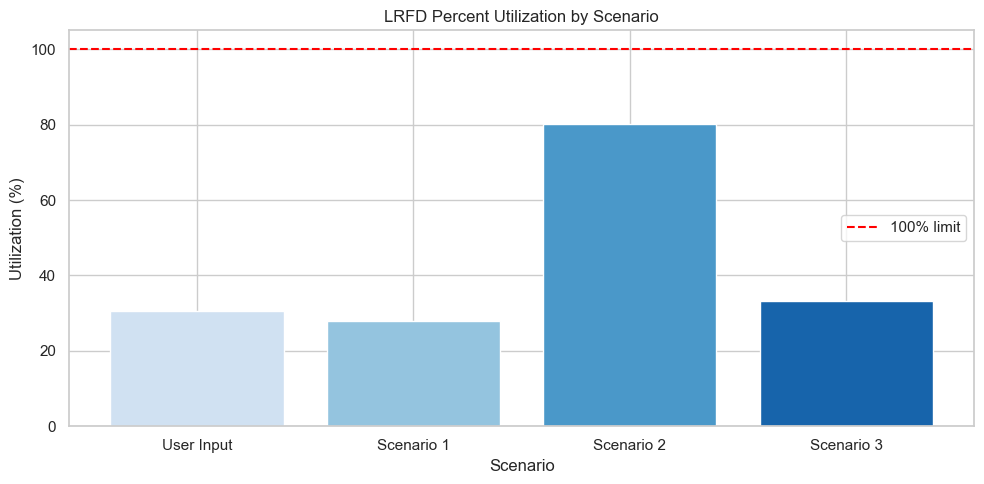

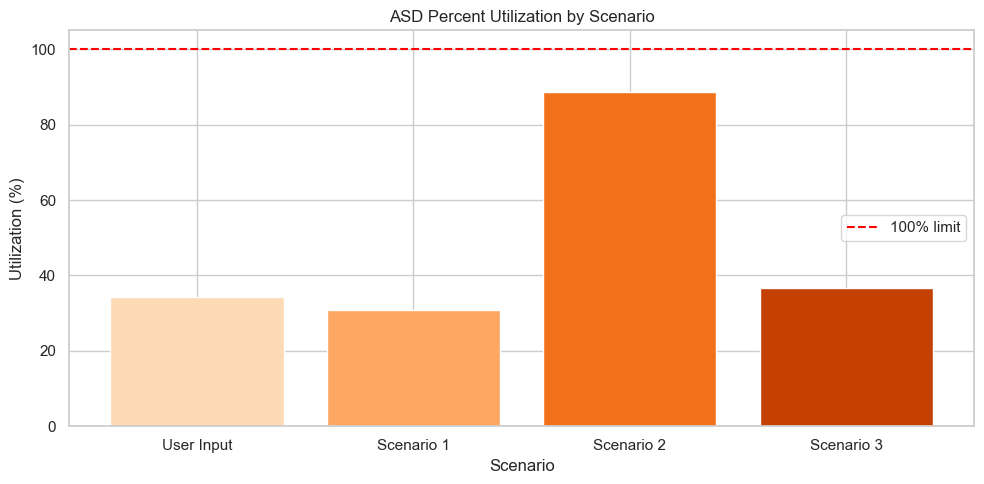

In [ ]:
#Apply a consistent visual style for both charts.
sns.set_theme(style="whitegrid")

#Build x positions and labels from scenario names.
x = np.arange(len(results))
labels = results["Scenario"].tolist()

#LRFD utilization chart.
plt.figure(figsize=(10, 5))
plt.bar(x, results["LRFD Utilization (%)"], color=sns.color_palette("Blues", len(results)))
plt.axhline(100, color="red", linestyle="--", linewidth=1.5, label="100% limit")
plt.ylabel("Utilization (%)")
plt.xlabel("Scenario")
plt.title("LRFD Percent Utilization by Scenario")
plt.xticks(x, labels)
plt.legend()
plt.tight_layout()
plt.show()

#ASD utilization chart.
plt.figure(figsize=(10, 5))
plt.bar(x, results["ASD Utilization (%)"], color=sns.color_palette("Oranges", len(results)))
plt.axhline(100, color="red", linestyle="--", linewidth=1.5, label="100% limit")
plt.ylabel("Utilization (%)")
plt.xlabel("Scenario")
plt.title("ASD Percent Utilization by Scenario")
plt.xticks(x, labels)
plt.legend()
plt.tight_layout()
plt.show()